# Parte 1 — Pipeline Baselines Frozen

```
Videos InHARD
    └─> DataLoader
           ├─> DINOv2 (frozen) ──> DINOv2_puro  (avg CLS)
           │                  ──> DINOv2_to_MCJEPA
           └─> V-JEPA2 (frozen) ─> VJEPA2_puro  (avg tokens)
                    │
             [MLP Clasificador × 3]
                    │
           Probabilidades
           ├─ Sin suavizado
           ├─ SMA
           ├─ EMA
           └─ Adaptive EMA
                    │
           Métricas: Accuracy · F1 weighted · F1 macro · ARI/NMI/Silhouette
```

## 0 · Instalación

In [ ]:
!pip uninstall -y transformers huggingface_hub tokenizers safetensors accelerate

!rm -rf /root/.cache/huggingface/modules/transformers_modules/facebook
!rm -rf /root/.cache/huggingface/hub/models--facebook--vjepa2-vitl-fpc64-256

!pip install -q --no-cache-dir \
    "huggingface_hub==0.35.3" \
    "tokenizers>=0.21,<0.22" \
    "safetensors>=0.4.5" \
    "accelerate>=0.34.0" \
    timm einops decord opencv-python matplotlib scikit-learn tqdm pandas

!pip install -q --no-cache-dir git+https://github.com/huggingface/transformers.git

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: huggingface_hub 1.16.1
Uninstalling huggingface_hub-1.16.1:
  Successfully uninstalled huggingface_hub-1.16.1
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
Found existing installation: safetensors 0.7.0
Uninstalling safetensors-0.7.0:
  Successfully uninstalled safetensors-0.7.0
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 kB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 347.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.2/507.2 kB 404.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 359.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 1 · Imports y configuración

In [ ]:
import os, cv2, json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from collections import deque
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    adjusted_rand_score, normalized_mutual_info_score, silhouette_score
)
from transformers import AutoImageProcessor, AutoModel, AutoVideoProcessor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# ── Configuración ──────────────────────────────────────────────────────────
INHARD_ROOT    = Path("/content/drive/MyDrive/01-InHARD/Segmented")
CHECKPOINT_DIR = Path("/content/drive/MyDrive/MC_JEPA_INHARD_CHECKPOINTS")

NUM_FRAMES  = 64
IMAGE_SIZE  = 224
BATCH_SIZE  = 4
VIDEO_EXTS  = {".mp4", ".avi", ".mov", ".mkv"}

DINO_MODEL_NAME = "facebook/dinov2-small"
HF_MODEL_ID     = "facebook/vjepa2-vitl-fpc64-256"

DEVICE: cuda


## 2 · Google Drive y Hugging Face

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from huggingface_hub import login
from getpass import getpass

hf_token = getpass("Token de Hugging Face: ")
login(token=hf_token)

Mounted at /content/drive
Token de Hugging Face: ··········


## 3 · Dataset InHARD → DataLoader

Clases: 14 | Train: 3711 | Val: 796 | Test: 796
Clases: ['Assemble system', 'Consult sheets', 'No action', 'Picking in front', 'Picking left', 'Put down component', 'Put down measuring rod', 'Put down screwdriver', 'Put down subsystem', 'Take component', 'Take measuring rod', 'Take screwdriver', 'Take subsystem', 'Turn sheets']


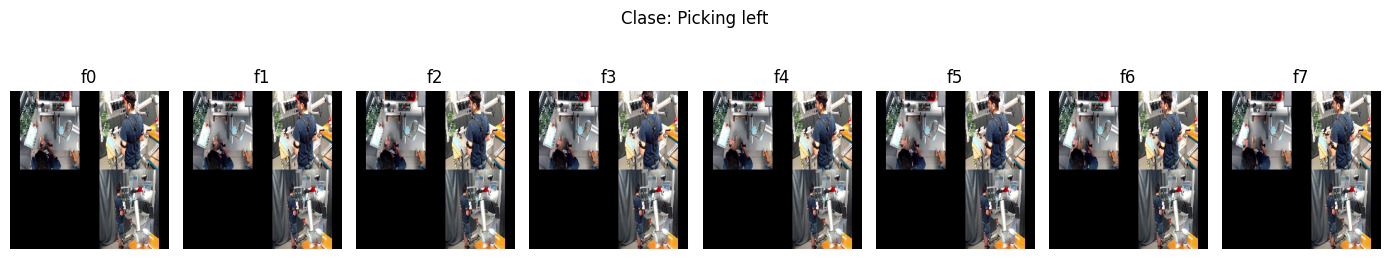

In [ ]:
# ── Lectura de video ──────────────────────────────────────────────────────

def read_video_frames(path, num_frames=8, image_size=224):
    cap = cv2.VideoCapture(str(path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        raise ValueError(f"Sin frames: {path}")
    idxs = np.linspace(0, total - 1, num_frames).astype(int)
    frames = []
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, f = cap.read()
        if not ok:
            continue
        f = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
        f = cv2.resize(f, (image_size, image_size))
        frames.append(Image.fromarray(f))
    cap.release()
    if not frames:
        raise ValueError(f"Sin frames extraídos: {path}")
    while len(frames) < num_frames:
        frames.append(frames[-1].copy())
    return frames[:num_frames]


class InHARDVideoDataset(Dataset):
    def __init__(self, samples, class_to_idx, num_frames=8, image_size=224):
        self.samples      = samples
        self.class_to_idx = class_to_idx
        idx2c = {v: k for k, v in class_to_idx.items()}
        self.classes      = [idx2c[i] for i in range(len(idx2c))]
        self.num_frames   = num_frames
        self.image_size   = image_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            frames = read_video_frames(path, self.num_frames, self.image_size)
        except Exception:
            frames = [Image.new("RGB", (self.image_size, self.image_size))] * self.num_frames
        return {"frames": frames, "label": label, "path": str(path)}


def collate_fn(batch):
    return (
        [b["frames"] for b in batch],
        torch.tensor([b["label"] for b in batch], dtype=torch.long),
        [b["path"] for b in batch]
    )


def build_inhard_splits(root, num_frames=8, image_size=224,
                         test_size=0.15, val_size=0.15, random_state=42):
    videos = sorted([p for p in Path(root).rglob("*") if p.suffix.lower() in VIDEO_EXTS])
    if not videos:
        raise ValueError(f"Sin videos en: {root}")
    labels_text = [p.parent.name for p in videos]
    classes     = sorted(set(labels_text))
    c2i         = {c: i for i, c in enumerate(classes)}
    labels      = [c2i[c] for c in labels_text]
    samples     = list(zip(videos, labels))

    train_val, test_s = train_test_split(
        samples, test_size=test_size, random_state=random_state, stratify=labels)
    tv_labels = [l for _, l in train_val]
    train_s, val_s = train_test_split(
        train_val, test_size=val_size / (1 - test_size),
        random_state=random_state, stratify=tv_labels)

    mk = lambda s: InHARDVideoDataset(s, c2i, num_frames, image_size)
    return mk(train_s), mk(val_s), mk(test_s), classes, c2i


train_ds, val_ds, test_ds, classes, class_to_idx = build_inhard_splits(
    INHARD_ROOT, num_frames=NUM_FRAMES, image_size=IMAGE_SIZE)
NUM_CLASSES = len(classes)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f"Clases: {NUM_CLASSES} | Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print("Clases:", train_ds.classes)

# Visualización de muestra
frames_sample, labels_sample, _ = next(iter(train_loader))
plt.figure(figsize=(14, 3))
for i in range(min(8, NUM_FRAMES)):
    plt.subplot(1, 8, i + 1)
    plt.imshow(frames_sample[0][i])
    plt.axis("off")
    plt.title(f"f{i}")
plt.suptitle(f"Clase: {train_ds.classes[labels_sample[0].item()]}")
plt.tight_layout()
plt.show()

## 4 · Extractores frozen: DINOv2 y V-JEPA2

In [ ]:
# ── DINOv2 (frozen) ─────────────────────────────────────────────────────────

class DINOv2Extractor(nn.Module):
    """Devuelve token CLS por frame → [B, T, D]."""
    def __init__(self, model_name):
        super().__init__()
        print(f"Cargando DINOv2: {model_name}")
        self.processor = AutoImageProcessor.from_pretrained(model_name)
        self.model     = AutoModel.from_pretrained(model_name).to(DEVICE)
        self.model.eval()
        for p in self.model.parameters():
            p.requires_grad = False

    @torch.inference_mode()
    def forward(self, batch_frames):
        B, T = len(batch_frames), len(batch_frames[0])
        flat = [img for vf in batch_frames for img in vf]
        inputs = self.processor(images=flat, return_tensors="pt").to(DEVICE)
        out = self.model(**inputs)
        feats = out.last_hidden_state[:, 0] if hasattr(out, "last_hidden_state") else out.pooler_output
        return feats.view(B, T, -1)   # [B, T, D_dino]


# ── V-JEPA2 (frozen) ─────────────────────────────────────────────────────────

class VJEPA2Extractor(nn.Module):
    """Devuelve promedio de tokens spatio-temporales → [B, D_vjepa2]."""
    def __init__(self, model, processor, device):
        super().__init__()
        self.model     = model
        self.processor = processor
        self.device    = device
        self.model.eval()

    @staticmethod
    def _to_numpy(batch_frames):
        return [np.stack([np.array(img.convert("RGB")) for img in vf]) for vf in batch_frames]

    @staticmethod
    def _extract_tokens(outputs):
        if hasattr(outputs, "last_hidden_state"):
            t = outputs.last_hidden_state
        elif isinstance(outputs, tuple):
            t = outputs[0]
        elif isinstance(outputs, dict):
            for key in ("last_hidden_state", "x_norm_patchtokens"):
                if key in outputs: t = outputs[key]; break
            else:
                t = list(outputs.values())[0]
        else:
            t = outputs
        if t.ndim == 4:
            B, T, N, D = t.shape; t = t.reshape(B, T * N, D)
        elif t.ndim == 2:
            t = t.unsqueeze(1)
        return t   # [B, N, D]

    @torch.inference_mode()
    def forward(self, batch_frames):
        videos = self._to_numpy(batch_frames)
        inputs = self.processor(videos=videos, return_tensors="pt")
        inputs = {k: v.to(self.device) if torch.is_tensor(v) else v for k, v in inputs.items()}
        try:
            outputs = self.model(**inputs, skip_predictor=True)
        except TypeError:
            outputs = self.model(**inputs)
        tokens = self._extract_tokens(outputs)
        return tokens.mean(dim=1)   # [B, D_vjepa2]


# ── Cargar modelos ────────────────────────────────────────────────────────────

dino_extractor = DINOv2Extractor(DINO_MODEL_NAME)
print("DINOv2 listo.")

vjepa2_processor = AutoVideoProcessor.from_pretrained(HF_MODEL_ID, trust_remote_code=True)
vjepa2_enc_base  = AutoModel.from_pretrained(HF_MODEL_ID, trust_remote_code=True).to(DEVICE)
vjepa2_enc_base.eval()
for p in vjepa2_enc_base.parameters():
    p.requires_grad = False
vjepa2_extractor = VJEPA2Extractor(vjepa2_enc_base, vjepa2_processor, DEVICE)
print("V-JEPA2 listo.")

# Detectar dimensiones
_fb, _lb, _pb = next(iter(train_loader))
with torch.inference_mode():
    _dino_seq  = dino_extractor(_fb)
    _vjepa_vec = vjepa2_extractor(_fb)
D_DINO   = _dino_seq.shape[-1]
D_VJEPA2 = _vjepa_vec.shape[-1]
print(f"D_DINO={D_DINO} | D_VJEPA2={D_VJEPA2}")

Cargando DINOv2: facebook/dinov2-small


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

...

video_preprocessor_config.json:   0%|          | 0.00/1.30k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/785 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.30G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

V-JEPA2 listo.
D_DINO=384 | D_VJEPA2=1024


## 5 · DINOv2 → módulo MC-JEPA-like (feature extractor)

In [ ]:
class DinoToMCJEPAEncoder(nn.Module):
    """
    Toma la secuencia de frames DINOv2 [B, T, D_dino] y
    produce un embedding multi-escala [B, hidden*3] usando
    tres encoders Transformer (short / mid / global).
    Se usa como extractor de características, NO se fine-tunea aquí.
    """
    def __init__(self, d_in, hidden=256, nhead=4, layers=1):
        super().__init__()
        self.proj = nn.Linear(d_in, hidden)
        self.short_encoder  = self._mk(hidden, nhead, layers)
        self.mid_encoder    = self._mk(hidden, nhead, layers)
        self.global_encoder = self._mk(hidden, nhead, layers)
        self.norm = nn.LayerNorm(hidden * 3)

    def _mk(self, h, n, l):
        return nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=h, nhead=n, dim_feedforward=h * 4,
                dropout=0.1, batch_first=True, activation="gelu"),
            num_layers=l)

    def forward(self, dino_seq):
        x = self.proj(dino_seq)           # [B, T, hidden]
        T = x.shape[1]
        sl, ml = max(1, T // 4), max(1, T // 2)
        zs = self.short_encoder(x[:, -sl:]).mean(1)
        zm = self.mid_encoder(x[:, -ml:]).mean(1)
        zg = self.global_encoder(x).mean(1)
        return self.norm(torch.cat([zs, zm, zg], dim=-1))   # [B, hidden*3]


dino_to_mcjepa_encoder = DinoToMCJEPAEncoder(d_in=D_DINO, hidden=256, nhead=4, layers=1).to(DEVICE)
dino_to_mcjepa_encoder.eval()   # Sin entrenamiento en esta parte

# Dimensión de salida
with torch.inference_mode():
    _dmc = dino_to_mcjepa_encoder(dino_extractor(_fb))
D_MCJEPA = _dmc.shape[-1]
print(f"D_MCJEPA (DinoToMCJEPA output dim): {D_MCJEPA}")

D_MCJEPA (DinoToMCJEPA output dim): 768


## 6 · Extracción de representaciones

In [ ]:
@torch.inference_mode()
def extract_embeddings(loader, rep_name, max_batches=None):
    """
    Extrae embeddings para una representación dada.
    rep_name: 'DINOv2_puro' | 'DINOv2_to_MCJEPA' | 'VJEPA2_puro'
    """
    X_list, y_list = [], []
    dino_to_mcjepa_encoder.eval()

    for i, (frames, labels, _) in enumerate(tqdm(loader, desc=rep_name)):
        if max_batches and i >= max_batches:
            break
        if rep_name == "DINOv2_puro":
            # Promedio de embeddings CLS por frame
            X = dino_extractor(frames).mean(dim=1)        # [B, D_dino]
        elif rep_name == "DINOv2_to_MCJEPA":
            # Secuencia DINOv2 → módulo MC-JEPA
            X = dino_to_mcjepa_encoder(dino_extractor(frames))   # [B, D_mcjepa]
        elif rep_name == "VJEPA2_puro":
            # Vector de video V-JEPA2
            X = vjepa2_extractor(frames)                  # [B, D_vjepa2]
        else:
            raise ValueError(f"Representación desconocida: {rep_name}")
        X_list.append(X.cpu())
        y_list.append(labels.cpu())

    return torch.cat(X_list).float(), torch.cat(y_list).long()


# ── Extraer para los tres loaders ────────────────────────────────────────────
REP_NAMES = ["DINOv2_puro", "DINOv2_to_MCJEPA", "VJEPA2_puro"]
MAX_BATCHES_EXTRACT = 30   # Aumentar para dataset completo

embeddings = {}   # {rep_name: {"train": (X, y), "val": (X, y), "test": (X, y)}}

for rep in REP_NAMES:
    print(f"\nExtrayendo: {rep}")
    embeddings[rep] = {
        "train": extract_embeddings(train_loader, rep, max_batches=MAX_BATCHES_EXTRACT),
        "val":   extract_embeddings(val_loader,   rep, max_batches=MAX_BATCHES_EXTRACT // 3),
        "test":  extract_embeddings(test_loader,  rep, max_batches=MAX_BATCHES_EXTRACT // 3),
    }
    Xtr, ytr = embeddings[rep]["train"]
    print(f"  Train: {Xtr.shape}  |  Val: {embeddings[rep]['val'][0].shape}  |  Test: {embeddings[rep]['test'][0].shape}")


Extrayendo: DINOv2_puro


DINOv2_puro:   0%|          | 0/928 [00:00<?, ?it/s]

DINOv2_puro:   0%|          | 0/199 [00:00<?, ?it/s]

DINOv2_puro:   0%|          | 0/199 [00:00<?, ?it/s]

  Train: torch.Size([120, 384])  |  Val: torch.Size([40, 384])  |  Test: torch.Size([40, 384])

Extrayendo: DINOv2_to_MCJEPA


...

  Train: torch.Size([120, 768])  |  Val: torch.Size([40, 768])  |  Test: torch.Size([40, 768])

Extrayendo: VJEPA2_puro


VJEPA2_puro:   0%|          | 0/928 [00:00<?, ?it/s]

VJEPA2_puro:   0%|          | 0/199 [00:00<?, ?it/s]

VJEPA2_puro:   0%|          | 0/199 [00:00<?, ?it/s]

  Train: torch.Size([120, 1024])  |  Val: torch.Size([40, 1024])  |  Test: torch.Size([40, 1024])


## 7 · Clasificador MLP

In [ ]:
class EmbeddingMLPClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    losses, y_true, y_pred = [], [], []
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        logits = model(X)
        loss = criterion(logits, y)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        losses.append(loss.item())
        y_true.extend(y.cpu().numpy())
        y_pred.extend(logits.argmax(1).detach().cpu().numpy())
    return {
        "loss": float(np.mean(losses)),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted",
                                labels=list(range(NUM_CLASSES)), zero_division=0)
    }


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    losses, y_true, y_pred, all_logits = [], [], [], []
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        logits = model(X)
        losses.append(criterion(logits, y).item())
        y_true.extend(y.cpu().numpy())
        y_pred.extend(logits.argmax(1).cpu().numpy())
        all_logits.extend(logits.detach().cpu().numpy())
    return {
        "loss": float(np.mean(losses)),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted",
                                labels=list(range(NUM_CLASSES)), zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro",
                              labels=list(range(NUM_CLASSES)), zero_division=0),
        "report": classification_report(y_true, y_pred, labels=list(range(NUM_CLASSES)),
                                        target_names=train_ds.classes, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))),
        "y_true": np.array(y_true),
        "y_pred": np.array(y_pred),
        "logits": np.array(all_logits)
    }


def train_mlp(rep_name, epochs=10, batch_size=32, lr=1e-3):
    print("\n" + "="*70)
    print(f"ENTRENANDO MLP: {rep_name}")
    print("="*70)

    X_tr, y_tr = embeddings[rep_name]["train"]
    X_vl, y_vl = embeddings[rep_name]["val"]
    X_ts, y_ts = embeddings[rep_name]["test"]

    mk_loader = lambda X, y, sh: DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=sh)
    tr_l = mk_loader(X_tr, y_tr, True)
    vl_l = mk_loader(X_vl, y_vl, False)
    ts_l = mk_loader(X_ts, y_ts, False)

    model     = EmbeddingMLPClassifier(X_tr.shape[1], NUM_CLASSES).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    best_f1, best_state, history = -1, None, []
    for epoch in range(1, epochs + 1):
        tr = train_epoch(model, tr_l, optimizer, criterion)
        vl = eval_epoch(model, vl_l)
        history.append({"rep": rep_name, "epoch": epoch,
                         "train_f1": tr["f1_weighted"], "val_f1": vl["f1_weighted"]})
        print(f"  Epoch {epoch:02d} | train_f1={tr['f1_weighted']:.4f} | val_f1={vl['f1_weighted']:.4f}")
        if vl["f1_weighted"] > best_f1:
            best_f1 = vl["f1_weighted"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state:
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    test_metrics = eval_epoch(model, ts_l)
    print(f"  TEST  acc={test_metrics['accuracy']:.4f} | f1_w={test_metrics['f1_weighted']:.4f}")
    print(test_metrics["report"])

    return {
        "rep": rep_name,
        "model": model,
        "history": pd.DataFrame(history),
        "test_metrics": test_metrics,
        "test_loader": ts_l
    }

## 8 · Entrenar clasificadores MLP × 3

In [ ]:
classifier_results = {}

for rep in REP_NAMES:
    classifier_results[rep] = train_mlp(rep, epochs=10, batch_size=32, lr=1e-3)

print("\nClasificadores entrenados:", list(classifier_results.keys()))


ENTRENANDO MLP: DINOv2_puro
  Epoch 01 | train_f1=0.0639 | val_f1=0.0105
  Epoch 02 | train_f1=0.1484 | val_f1=0.1678
  Epoch 03 | train_f1=0.1295 | val_f1=0.1585
  Epoch 04 | train_f1=0.1813 | val_f1=0.1778
  Epoch 05 | train_f1=0.1910 | val_f1=0.1808
  Epoch 06 | train_f1=0.2494 | val_f1=0.1931
  Epoch 07 | train_f1=0.2337 | val_f1=0.1945
  Epoch 08 | train_f1=0.2865 | val_f1=0.2011
  Epoch 09 | train_f1=0.3238 | val_f1=0.1904
  Epoch 10 | train_f1=0.3234 | val_f1=0.2821
  TEST  acc=0.3000 | f1_w=0.2107
                        precision    recall  f1-score   support

       Assemble system       0.35      0.90      0.50        10
        Consult sheets       0.00      0.00      0.00         0
             No action       0.20      0.50      0.29         2
      Picking in front       0.00      0.00      0.00         2
          Picking left       0.50      0.20      0.29        10
    Put down component       0.00      0.00      0.00         3
Put down measuring rod       0.00      

## 9 · Suavizadores de probabilidades

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Cuatro estrategias de suavizado aplicadas a las probabilidades de salida MLP
# ─────────────────────────────────────────────────────────────────────────────

class NoSmoother:
    """Sin suavizado — probabilidades directas del MLP."""
    def reset(self): pass
    def update(self, probs): return probs


class SMASmoother:
    """Simple Moving Average sobre ventana de `window_size` pasos."""
    def __init__(self, window_size=5):
        self.buf = deque(maxlen=window_size)
    def reset(self): self.buf.clear()
    def update(self, probs):
        self.buf.append(probs)
        s = np.mean(np.stack(self.buf), axis=0)
        return s / s.sum()


class EMASmoother:
    """Exponential Moving Average con alpha fijo."""
    def __init__(self, alpha=0.35):
        self.alpha = alpha; self.state = None
    def reset(self): self.state = None
    def update(self, probs):
        self.state = probs.copy() if self.state is None                      else self.alpha * probs + (1 - self.alpha) * self.state
        self.state /= self.state.sum()
        return self.state


class AdaptiveEMASmoother:
    """EMA con alpha que aumenta conforme sube la confianza del modelo."""
    def __init__(self, alpha_min=0.15, alpha_max=0.75, confidence_threshold=0.55):
        self.a_min = alpha_min; self.a_max = alpha_max
        self.thr   = confidence_threshold; self.state = None
    def reset(self): self.state = None
    def update(self, probs):
        c     = float(np.max(probs))
        alpha = self.a_min if c < self.thr                 else self.a_min + (self.a_max - self.a_min) * c
        self.state = probs.copy() if self.state is None                      else alpha * probs + (1 - alpha) * self.state
        self.state /= self.state.sum()
        return self.state


def make_smoothers():
    return {
        "No_smoothing":    NoSmoother(),
        "SMA_probs":       SMASmoother(window_size=5),
        "EMA_probs":       EMASmoother(alpha=0.35),
        "Adaptive_EMA":    AdaptiveEMASmoother(alpha_min=0.15, alpha_max=0.75)
    }

print("Suavizadores definidos: No_smoothing · SMA_probs · EMA_probs · Adaptive_EMA")

Suavizadores definidos: No_smoothing · SMA_probs · EMA_probs · Adaptive_EMA


## 10 · Evaluación con suavizado → Métricas

In [ ]:
@torch.no_grad()
def get_raw_logits(model, loader):
    """Obtiene logits en orden secuencial desde el test_loader de embeddings."""
    model.eval()
    all_logits, all_labels = [], []
    for X, y in loader:
        logits = model(X.to(DEVICE))
        all_logits.extend(logits.cpu().numpy())
        all_labels.extend(y.numpy())
    return np.array(all_logits), np.array(all_labels)


def evaluate_with_all_smoothers(logits, labels, num_classes, class_names):
    smoothers = make_smoothers()
    probs_all  = F.softmax(torch.tensor(logits), dim=-1).numpy()
    results    = {}
    for sname, smoother in smoothers.items():
        smoother.reset()
        y_pred = []
        for probs in probs_all:
            y_pred.append(int(np.argmax(smoother.update(probs))))
        y_true = labels.tolist()
        results[sname] = {
            "accuracy":    accuracy_score(y_true, y_pred),
            "f1_weighted": f1_score(y_true, y_pred, average="weighted",
                                    labels=list(range(num_classes)), zero_division=0),
            "f1_macro":    f1_score(y_true, y_pred, average="macro",
                                    labels=list(range(num_classes)), zero_division=0),
            "confusion_matrix": confusion_matrix(y_true, y_pred, labels=list(range(num_classes))),
            "report": classification_report(y_true, y_pred, labels=list(range(num_classes)),
                                            target_names=class_names, zero_division=0),
            "y_true": np.array(y_true),
            "y_pred": np.array(y_pred)
        }
    return results


# ── Correr evaluación completa ────────────────────────────────────────────────
all_rows = []
smoothing_details = {}

for rep, result in classifier_results.items():
    print(f"Evaluando suavizado: {rep}")
    logits, labels = get_raw_logits(result["model"], result["test_loader"])
    sm_results = evaluate_with_all_smoothers(logits, labels, NUM_CLASSES, train_ds.classes)
    smoothing_details[rep] = sm_results
    for sname, m in sm_results.items():
        all_rows.append({
            "model":       rep,
            "smoothing":   sname,
            "accuracy":    m["accuracy"],
            "f1_weighted": m["f1_weighted"],
            "f1_macro":    m["f1_macro"]
        })

final_df = pd.DataFrame(all_rows).sort_values(["f1_weighted", "accuracy"], ascending=False)
final_df

Evaluando suavizado: DINOv2_puro
Evaluando suavizado: DINOv2_to_MCJEPA
Evaluando suavizado: VJEPA2_puro


,model,smoothing,accuracy,f1_weighted,f1_macro
8,VJEPA2_puro,No_smoothing,0.475,0.392305,0.166373
4,DINOv2_to_MCJEPA,No_smoothing,0.300,0.269943,0.082127
10,VJEPA2_puro,EMA_probs,0.375,0.258242,0.073783
9,VJEPA2_puro,SMA_probs,0.300,0.211516,0.060433
0,DINOv2_puro,No_smoothing,0.300,0.210714,0.076531
11,VJEPA2_puro,Adaptive_EMA,0.250,0.164313,0.046947
1,DINOv2_puro,SMA_probs,0.250,0.100000,0.028571
2,DINOv2_puro,EMA_probs,0.250,0.100000,0.028571
3,DINOv2_puro,Adaptive_EMA,0.250,0.100000,0.028571
6,DINOv2_to_MCJEPA,EMA_probs,0.125,0.088690,0.028912


## 11 · Métricas de clustering (ARI / NMI / Silhouette)

In [ ]:
def clustering_metrics(X, y_true, name, num_clusters):
    km = KMeans(n_clusters=num_clusters, random_state=42, n_init="auto").fit_predict(X)
    return {
        "representation": name,
        "ARI":       adjusted_rand_score(y_true, km),
        "NMI":       normalized_mutual_info_score(y_true, km),
        "Silhouette": silhouette_score(X, km) if len(set(km)) > 1 else np.nan
    }


# Usar embeddings de test para clustering
cluster_rows = []
for rep in REP_NAMES:
    X_ts, y_ts = embeddings[rep]["test"]
    cluster_rows.append(clustering_metrics(X_ts.numpy(), y_ts.numpy(), rep, NUM_CLASSES))

cluster_df = pd.DataFrame(cluster_rows).sort_values("NMI", ascending=False)
cluster_df

,representation,ARI,NMI,Silhouette
1,DINOv2_to_MCJEPA,0.025130,0.508785,0.069484
0,DINOv2_puro,0.006670,0.508343,0.096580
2,VJEPA2_puro,-0.009479,0.489185,0.104714


## 12 · Gráficas comparativas

F1 weighted por modelo × suavizado


smoothing,Adaptive_EMA,EMA_probs,No_smoothing,SMA_probs
model,,,,
DINOv2_puro,0.100000,0.100000,0.210714,0.100000
DINOv2_to_MCJEPA,0.035139,0.088690,0.269943,0.072845
VJEPA2_puro,0.164313,0.258242,0.392305,0.211516



Accuracy por modelo × suavizado


smoothing,Adaptive_EMA,EMA_probs,No_smoothing,SMA_probs
model,,,,
DINOv2_puro,0.250,0.250,0.300,0.250
DINOv2_to_MCJEPA,0.075,0.125,0.300,0.125
VJEPA2_puro,0.250,0.375,0.475,0.300


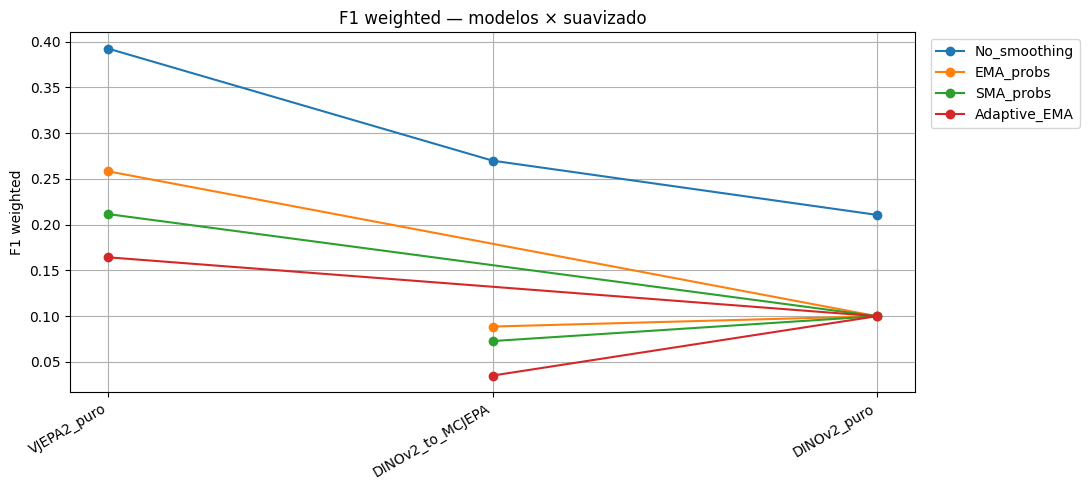

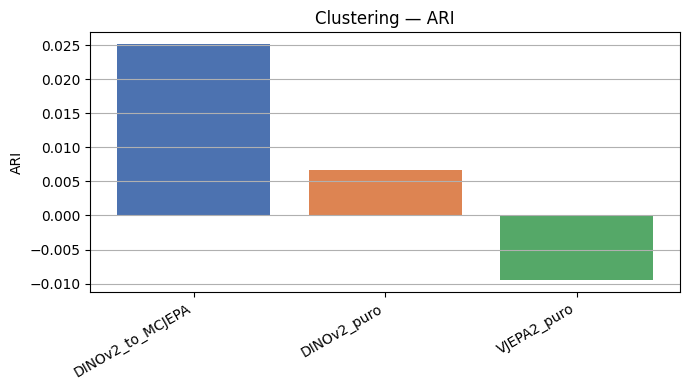

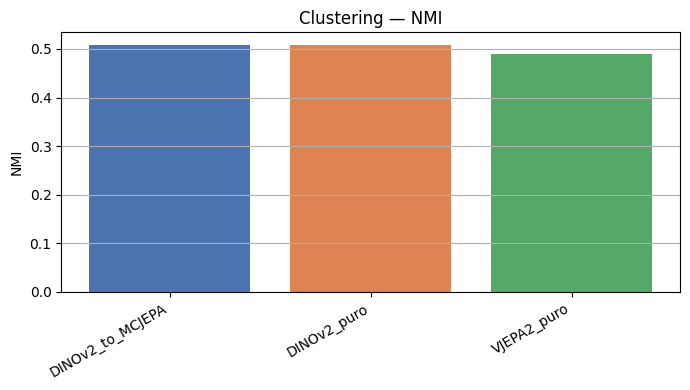

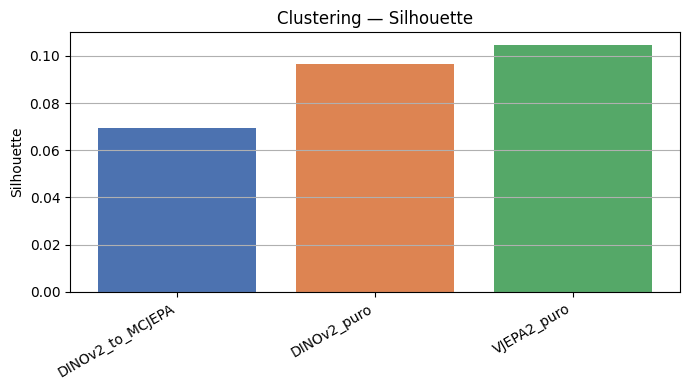

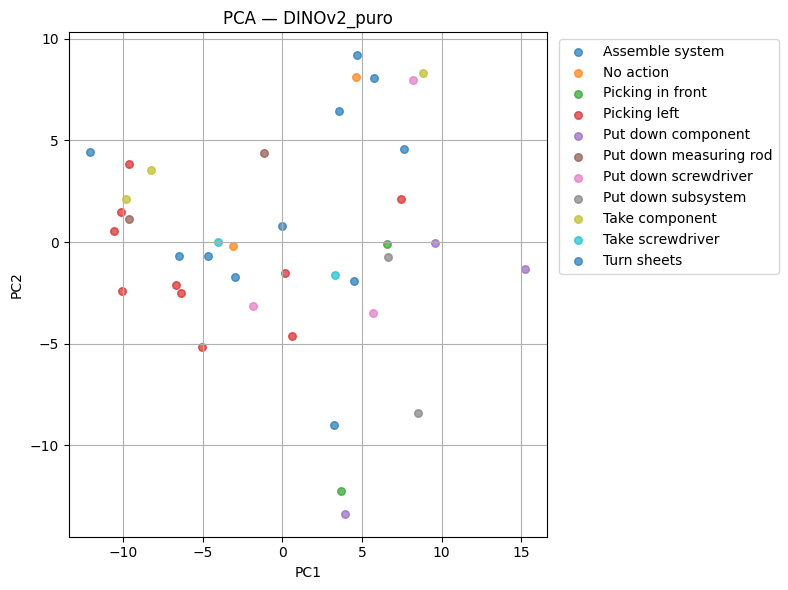

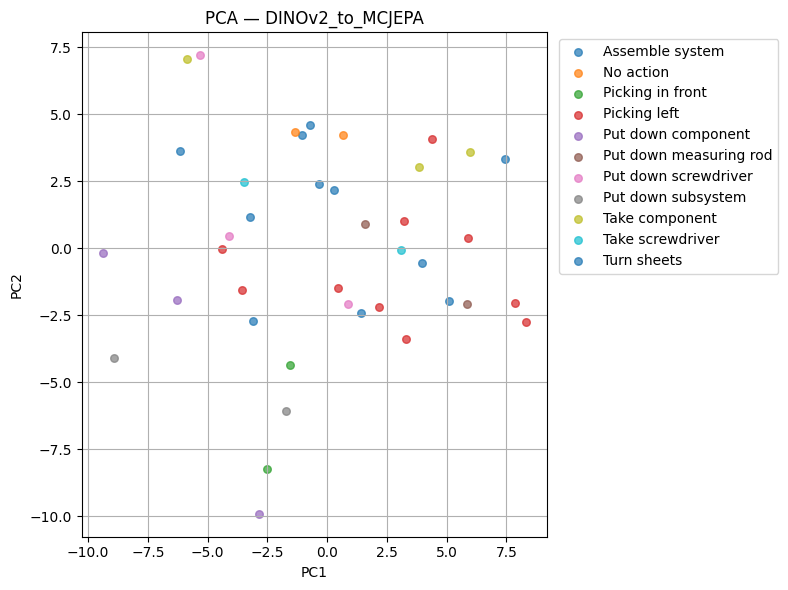

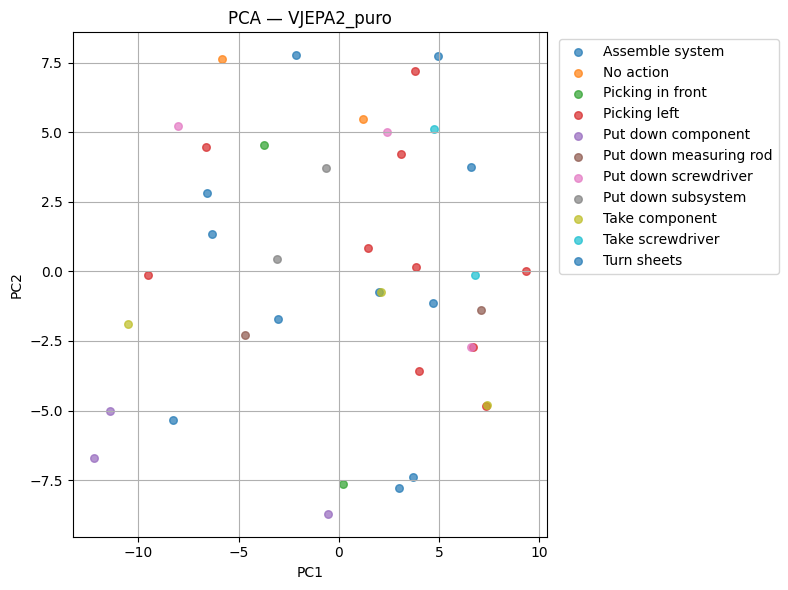

In [ ]:
# ── Tabla pivote F1 weighted ───────────────────────────────────────────────

f1_pivot = final_df.pivot_table(index="model", columns="smoothing", values="f1_weighted")
print("F1 weighted por modelo × suavizado")
display(f1_pivot)

acc_pivot = final_df.pivot_table(index="model", columns="smoothing", values="accuracy")
print("\nAccuracy por modelo × suavizado")
display(acc_pivot)

# ── Líneas F1 por suavizado ───────────────────────────────────────────────────

plt.figure(figsize=(11, 5))
for sname in final_df["smoothing"].unique():
    df_s = final_df[final_df["smoothing"] == sname]
    plt.plot(df_s["model"], df_s["f1_weighted"], marker="o", label=sname)
plt.xticks(rotation=30, ha="right")
plt.ylabel("F1 weighted")
plt.title("F1 weighted — modelos × suavizado")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Barras de clustering ──────────────────────────────────────────────────────

for metric in ["ARI", "NMI", "Silhouette"]:
    plt.figure(figsize=(7, 4))
    plt.bar(cluster_df["representation"], cluster_df[metric], color=["#4C72B0","#DD8452","#55A868"])
    plt.title(f"Clustering — {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

# ── PCA representaciones ──────────────────────────────────────────────────────

def plot_pca(X, y, title):
    Z = PCA(n_components=2, random_state=42).fit_transform(X)
    plt.figure(figsize=(8, 6))
    for ci, cn in enumerate(train_ds.classes):
        idx = y == ci
        if idx.sum() == 0: continue
        plt.scatter(Z[idx, 0], Z[idx, 1], label=cn, alpha=0.7, s=30)
    plt.title(title); plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left"); plt.grid(True)
    plt.tight_layout(); plt.show()

for rep in REP_NAMES:
    X_ts, y_ts = embeddings[rep]["test"]
    plot_pca(X_ts.numpy(), y_ts.numpy(), f"PCA — {rep}")

## 13 · Mejor configuración

In [ ]:
best = final_df.iloc[0]
print("MEJOR CONFIGURACIÓN")
print("=" * 40)
print(f"  Modelo:      {best['model']}")
print(f"  Suavizado:   {best['smoothing']}")
print(f"  Accuracy:    {best['accuracy']:.4f}")
print(f"  F1 weighted: {best['f1_weighted']:.4f}")
print(f"  F1 macro:    {best['f1_macro']:.4f}")

MEJOR CONFIGURACIÓN
  Modelo:      VJEPA2_puro
  Suavizado:   No_smoothing
  Accuracy:    0.4750
  F1 weighted: 0.3923
  F1 macro:    0.1664


## 14 · Guardar checkpoints

In [ ]:
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ── Encoder DINOv2 → MC-JEPA ──────────────────────────────────────────────────
torch.save({
    "state_dict": dino_to_mcjepa_encoder.state_dict(),
    "D_DINO": D_DINO, "hidden": 256, "nhead": 4, "layers": 1
}, CHECKPOINT_DIR / "dino_to_mcjepa_encoder.pt")

# ── Clasificadores MLP ────────────────────────────────────────────────────────
clf_dir = CHECKPOINT_DIR / "embedding_classifiers"
clf_dir.mkdir(parents=True, exist_ok=True)
for rep, res in classifier_results.items():
    X_tr, _ = embeddings[rep]["train"]
    torch.save({
        "rep_name": rep,
        "state_dict": res["model"].state_dict(),
        "input_dim": X_tr.shape[1],
        "num_classes": NUM_CLASSES,
        "class_names": train_ds.classes
    }, clf_dir / f"{rep}_classifier.pt")
print("Clasificadores guardados.")

# ── Embeddings para Parte 2 ───────────────────────────────────────────────────
emb_dir = CHECKPOINT_DIR / "embeddings_parte1"
emb_dir.mkdir(parents=True, exist_ok=True)
for rep in REP_NAMES:
    for split in ["train", "val", "test"]:
        X, y = embeddings[rep][split]
        np.save(emb_dir / f"{rep}_{split}_X.npy", X.numpy())
        np.save(emb_dir / f"{rep}_{split}_y.npy", y.numpy())
print("Embeddings guardados en:", emb_dir)

# ── Tablas CSV ────────────────────────────────────────────────────────────────
final_df.to_csv(CHECKPOINT_DIR / "parte1_smoothing_results.csv", index=False)
cluster_df.to_csv(CHECKPOINT_DIR / "parte1_clustering.csv", index=False)
f1_pivot.to_csv(CHECKPOINT_DIR / "parte1_f1_pivot.csv")

# ── Config ────────────────────────────────────────────────────────────────────
with open(CHECKPOINT_DIR / "config.json", "w") as fp:
    json.dump({
        "DINO_MODEL_NAME": DINO_MODEL_NAME,
        "HF_MODEL_ID": HF_MODEL_ID,
        "NUM_CLASSES": NUM_CLASSES,
        "class_names": train_ds.classes,
        "NUM_FRAMES": NUM_FRAMES,
        "IMAGE_SIZE": IMAGE_SIZE,
        "BATCH_SIZE": BATCH_SIZE
    }, fp, indent=4)

print("\nTodo guardado en:", CHECKPOINT_DIR)

Clasificadores guardados.
Embeddings guardados en: /content/drive/MyDrive/MC_JEPA_INHARD_CHECKPOINTS/embeddings_parte1

Todo guardado en: /content/drive/MyDrive/MC_JEPA_INHARD_CHECKPOINTS
